# Human-in-the-Loop (HITL) Workflows in LangGraph

An agentic graph that always runs end to end without stopping is dangerous the moment it can take a consequential action: sending a message, calling a paid API, deleting data, or answering a question it should not answer unsupervised. Human-in-the-loop workflows solve this by letting a graph pause at a chosen point, hand control back to a human (or any external process), and only continue once that human has approved, edited, or supplied missing information.

**Why interrupts matter**

- **Approval gates**: a node can stop right before a sensitive action and ask "should this proceed?" instead of proceeding blindly.
- **Editable state**: the value returned from the pause point can be arbitrary data, not just yes/no, so a human can correct or augment what the graph is about to do.
- **Sign-off on sensitive actions**: any step with real-world consequences (spending money, sending communications, executing code) can be gated behind explicit human consent before it runs.

**Relationship to checkpointers and persistence**

Pausing a graph mid-run is only possible because its state can be saved and reloaded. This notebook builds directly on the persistence notebook: a `checkpointer` (here `MemorySaver`) is passed into `.compile(...)`, and every invocation is scoped to a `thread_id` in the `config`. When a node calls `interrupt(...)`, LangGraph checkpoints the state as it exists at that point, associates it with the thread, and returns control to the caller. Without a checkpointer, there is nowhere to store the paused state, and resuming would be impossible.

**The interrupt/resume mechanism**

The mechanism has two halves:

1. `interrupt(payload)`, called from inside a node, immediately halts the graph run and surfaces `payload` back to the caller through the result's `"__interrupt__"` key. The node function's execution stops at that line.
2. `Command(resume=value)`, passed as the input to a subsequent `invoke`/`stream` call (using the same `config`/`thread_id`), tells LangGraph to resume the paused run. Execution resumes inside the same node, at the same line, with the `interrupt(...)` call now returning `value` instead of pausing again.

Between these two calls, any external process — a terminal prompt, a web form, an API request — can decide what `value` should be. The graph itself is agnostic to how that decision is produced; it only cares about the shape of the resumed value.

Concretely, this notebook implements a single-node chat graph where the node pauses before calling the LLM, asks a human to approve the user's question, and either proceeds with the LLM call or short-circuits with a rejection message, depending on the human's answer.

## Imports

This cell brings in every primitive the human-in-the-loop pattern needs:

- `StateGraph`, `START`, `END` from `langgraph.graph` — the standard graph-building API.
- `add_messages` from `langgraph.graph.message` — the reducer used to accumulate chat messages in state instead of overwriting them.
- `MemorySaver` from `langgraph.checkpoint.memory` — an in-memory checkpointer. A checkpointer is not optional here: it is what lets a graph run pause mid-execution and be resumed later with the correct state.
- `interrupt` and `Command` from `langgraph.types` — the two core HITL primitives. `interrupt(payload)` is called from inside a node to halt execution and surface `payload` to whoever is running the graph. `Command(resume=value)` is what gets passed back into `invoke`/`stream` to continue execution, with `value` becoming the return value of the `interrupt(...)` call inside the node.
- `ChatOpenAI` — the LLM that will be invoked once a human approves a question.
- `AnyMessage`, `AIMessage`, `BaseMessage` from `langchain_core.messages` — message types used in the state schema and to construct a rejection message.
- `load_dotenv` — loads API keys from a `.env` file.
- `TypedDict`, `Annotated` — used to define the graph's state schema.

In [105]:
from typing import Annotated

from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage

## Loading environment variables

`load_dotenv()` reads a local `.env` file and populates environment variables such as the OpenAI API key. This must run before `ChatOpenAI` is instantiated so the client can authenticate.

In [106]:
load_dotenv()

True

## Instantiating the LLM

`llm = ChatOpenAI(model="gpt-4.1-mini")` creates the model client used inside the graph node. It is only actually invoked conditionally, after a human approves the pending question — if the question is rejected, the LLM is never called.

In [107]:
llm = ChatOpenAI(model="gpt-4.1-mini")

## State schema

`ChatState` is a `TypedDict` with a single field, `messages`, annotated with the `add_messages` reducer. Rather than replacing the list on every update, `add_messages` appends new messages to the existing list (matching messages by id are merged/updated). This matters for HITL specifically because the state persists across the pause: whatever is in `messages` when `interrupt(...)` fires is exactly what the checkpointer saves, and it is exactly what is still there when the run resumes after `Command(resume=...)`.

In [108]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

## The node: where the interrupt happens

`chat_node` is the single node in this graph, and it is where the entire HITL pattern lives.

- `interrupt({...})` is called with a payload dict: `type` (`"approval"`), `reason` (a human-readable description of what is about to happen), `question` (pulled from `state["messages"][-1].content`, i.e. the latest user message), and `instruction` (what response is expected from the human). Calling `interrupt(...)` immediately pauses the graph run at this line and surfaces this exact dict to the caller, who receives it via `result["__interrupt__"]`.
- The pause happens *before* any decision is known — the function has not returned yet, and `decision` has no value. Execution genuinely stops here until the run is resumed.
- On resume (via `Command(resume={"approved": ...})`), the same `interrupt(...)` call returns the resumed value, which is assigned to `decision`. This is the mechanism by which a human's answer re-enters the function body at the exact point it left off.
- The conditional logic based on that decision is simple and entirely local to the node: if `decision["approved"] == 'no'`, the node returns an `AIMessage` saying "Not approved." and the LLM is never called. Otherwise, `llm.invoke(state["messages"])` runs and its response is returned. There is no separate conditional edge in the graph for this — the branch is handled inline after the interrupt returns.

In [96]:
def chat_node(state: ChatState):

    decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer a user question.",
        "question": state["messages"][-1].content,
        "instruction": "Approve this question? yes/no"
    })
    
    if decision["approved"] == 'no':
        return {"messages": [AIMessage(content="Not approved.")]}

    else:
        response = llm.invoke(state["messages"])
        return {"messages": [response]}



## Building and compiling the graph

`StateGraph(ChatState)` is built with a single node, `"chat"`, wired `START -> chat -> END` — no conditional edges are needed because the approve/reject branch is handled inside `chat_node` itself, not at the graph-topology level.

`checkpointer = MemorySaver()` creates an in-memory checkpointer. As the comment in the cell notes, a checkpointer is required for interrupts: without one, `builder.compile(...)` would produce a graph that has no way to persist state at the point `interrupt(...)` is called, and therefore no way to resume it later with `Command(resume=...)`.

`app = builder.compile(checkpointer=checkpointer)` compiles the graph with that checkpointer attached, making every subsequent `invoke`/`stream` call against `app` capable of pausing and resuming as long as a consistent `thread_id` is used.

In [109]:
# 3. Build the graph: START -> chat -> END
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)

builder.add_edge(START, "chat")
builder.add_edge("chat", END)

# Checkpointer is required for interrupts
checkpointer = MemorySaver()

# Compile the app
app = builder.compile(checkpointer=checkpointer)

## Visualizing the graph

Displaying `app` renders the compiled graph's structure: `__start__ -> chat -> __end__`. This confirms the topology described above — one node, no branching at the graph level — before the two-phase invoke/resume pattern is exercised.

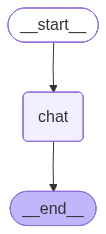

In [110]:
app

## Phase 1: the initial run, up to the interrupt

`config = {"configurable": {"thread_id": '1234'}}` identifies the conversation thread. This same `config` must be reused for the resume call later — it is how the checkpointer knows which paused run to resume.

`initial_input` supplies the first human message. `app.invoke(initial_input, config=config)` starts the graph: it enters `chat_node`, builds the interrupt payload, and calls `interrupt(...)`. At that exact line, execution stops. `invoke` does not run the graph to completion in this call — it returns as soon as the interrupt fires, with the state checkpointed under `thread_id` `'1234'` so it can be picked up later.

In [117]:
# Create a new thread id for this conversation
config = {"configurable": {"thread_id": '1234'}}

# ---- STEP 1: user asks a question ----
initial_input = {
    "messages": [
        ("user", "Explain gradient descent in very simple terms.")
    ]
}

# Invoke the graph for the first time
result = app.invoke(initial_input, config=config)

## Inspecting the paused state

`result` shows what a paused run looks like: a `messages` list holding the conversation so far (note that on this thread the list already contains messages from earlier runs against the same `thread_id`, since `MemorySaver` persists state across separate `invoke` calls made on that thread), plus a `"__interrupt__"` key. `"__interrupt__"` holds a list of `Interrupt` objects — a list because, in general, more than one interrupt could be pending. Each `Interrupt` object's `.value` is exactly the payload dict passed to `interrupt(...)` inside `chat_node`.

In [118]:
result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='d7bb9cc8-e132-4afe-a673-33d279309b83'),
  AIMessage(content='Not approved.', additional_kwargs={}, response_metadata={}, id='5b53bc94-8113-4b8e-8344-d9ebcf26d8a1'),
  HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='8b0dd45c-af99-497b-b665-9b25f0652427')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': 'Explain gradient descent in very simple terms.', 'instruction': 'Approve this question? yes/no'}, id='8f970c37f92bf4a907ec29209ca75371')]}

## Extracting the interrupt payload

`message = result['__interrupt__'][0].value` pulls the first (and here, only) pending interrupt's payload out of the result: the `type`, `reason`, `question`, and `instruction` dict that was passed to `interrupt(...)`. This is the data a human-facing surface (a terminal prompt, a UI, an API response) needs in order to decide how to respond.

In [119]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': 'Explain gradient descent in very simple terms.',
 'instruction': 'Approve this question? yes/no'}

## Collecting the human decision

`user_input = input(...)` is the human-in-the-loop step itself: a plain terminal prompt that displays the backend message and asks for a yes/no answer. This is the simplest possible stand-in for a real approval channel — a web form, a Slack button, an API call — and it illustrates that the graph does not care how the resume value is produced, only what shape it takes when it comes back.

In [120]:
user_input = input(f"\nBackend message - {message} \n Approve this question? (y/n): ")

## Phase 2: resuming with Command

`app.invoke(Command(resume={"approved": user_input}), config=config)` is the resume call. Two things make this a resume rather than a new run: passing a `Command` object (instead of a state dict) as the input, and reusing the identical `config` (same `thread_id`, `'1234'`) from the initial invocation. Given both, LangGraph loads the checkpointed state from the paused run and re-enters `chat_node` at the exact `interrupt(...)` call, which now returns `{"approved": user_input}` as `decision`.

From there, `chat_node` runs its conditional logic (reject vs. call the LLM) and returns normally, and since there is nothing left in the graph but the edge to `END`, this `invoke` call runs the graph to completion and returns the full final state — no further interrupt occurs in this run.

In [121]:
# Resume the graph with the approval decision
final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config=config,
)

## Reading the final result

`print(final_result["messages"][-1].content)` prints the last message from the completed run: either the LLM's answer (if the human approved) or the "Not approved." message (if the human rejected), depending on the value supplied to `Command(resume=...)`. This closes the loop from initial invoke, through the interrupt, to a human decision, to a resumed and completed graph run.

In [ ]:
print(final_result["messages"][-1].content)

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='d7bb9cc8-e132-4afe-a673-33d279309b83'), AIMessage(content='Not approved.', additional_kwargs={}, response_metadata={}, id='5b53bc94-8113-4b8e-8344-d9ebcf26d8a1'), HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='8b0dd45c-af99-497b-b665-9b25f0652427'), AIMessage(content='Sure! Imagine you\'re standing on a hill, and your goal is to reach the lowest point in the valley. However, it\'s foggy, so you can\'t see very far. To get down, you take small steps going downhill, always moving in the direction where the slope goes down the most. By repeating this—taking small steps downhill—you eventually reach the bottom.\n\nGradient descent is like that, but for finding the best solution in math or machine learning. Instead of a hill, you have a "function" to minimize (like an error or cost), and g

## Summary: HITL patterns and why they matter

This notebook demonstrates the **approval** pattern: a node pauses via `interrupt(...)` before taking an action (calling the LLM), a human is shown the pending action and asked to approve or reject it, and the graph resumes via `Command(resume=...)` with the human's decision determining which branch executes.

The same three primitives — `interrupt`, `Command(resume=...)`, and a checkpointer scoping state to a `thread_id` — generalize to other HITL patterns beyond approval:

- **Input**: a node can `interrupt(...)` to ask a human for information the graph does not have (a missing parameter, a clarifying answer) and resume with that value merged into its logic.
- **Editing**: a node can surface a proposed action or piece of state through `interrupt(...)` and let the human return a modified version via `Command(resume=...)`, rather than a simple accept/reject.

All three patterns rely on the same mechanics demonstrated here: the node pauses at `interrupt(...)`, the checkpointer preserves state at that exact point, an external actor decides what happens next, and `Command(resume=...)` re-enters the node with that decision. This is what makes agentic systems safe to deploy for consequential actions — the graph can be given the ability to act, while still requiring a human checkpoint before anything irreversible happens.